# Laboratorio 2 — Auditoría exploratoria de un conjunto de datos

Un conjunto de datos de mantenimiento industrial llega sin documentación: 4237 registros de
sensores de máquinas, con la variable `fallo` como objetivo. Antes de modelar nada hay que
saber **qué tiene adentro**.

El laboratorio recorre la auditoría completa: estructura, códigos de error, medidas de posición,
la forma de cada distribución, el diagrama de caja y lo que esconde, los atípicos, las
relaciones entre variables y los faltantes. Cada paso produce evidencia, y la evidencia decide
cómo se modela después.

**El entregable es el informe de hallazgos de la sección final**: por cada hallazgo, evidencia,
criterio, decisión y justificación. Lo que no se complete durante la clase se termina fuera de
ella; el informe se entrega igual.

Las celdas que contienen `raise NotImplementedError` deben completarse.

## 0. Preparación

El conjunto de datos se distribuye como archivo: `data/mantenimiento_industrial.csv`. Lo produce
el script `src/generar_dataset_sucio.py` con semilla fija, de modo que todos trabajan sobre
exactamente las mismas filas.

La celda siguiente lo busca en las ubicaciones habituales. En Google Colab, si no lo encuentra,
abre el diálogo de carga de archivos.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)

In [18]:
from pathlib import Path

NOMBRE = "mantenimiento_industrial.csv"
CANDIDATAS = [Path(NOMBRE), Path("data") / NOMBRE, Path("../data") / NOMBRE]


def cargar_datos() -> pd.DataFrame:
    """Carga el CSV del curso desde la primera ubicación donde exista.

    En Colab, si no está en ninguna, pide subirlo.
    """
    for ruta in CANDIDATAS:
        if ruta.exists():
            print(f"Cargado desde {ruta}")
            return pd.read_csv(ruta)
    try:
        from google.colab import files  # type: ignore
    except ImportError as exc:
        raise FileNotFoundError(
            f"No se encontró {NOMBRE}. Copiarlo junto al notebook."
        ) from exc
    files.upload()
    return pd.read_csv(NOMBRE)


df = cargar_datos()
df.shape

Cargado desde mantenimiento_industrial.csv


(4237, 14)

### Para analizar

Antes de calcular nada, corresponde mirar qué llegó: cuántas filas y columnas, de qué tipo es
cada una y qué valores toma.

In [19]:
df.head()

,id_registro,id_maquina,planta,modelo_equipo,turno,antiguedad_meses,horas_operacion,n_mantenimientos_previos,temperatura_c,vibracion_mm_s,presion_bar,consumo_kwh,costo_reparacion_usd,fallo
0,2355,MQ-0009,Este,XR-200,mañana,51.0,9644.0,2,NaN,3.778,4.61,547.2,NaN,0
1,2228,MQ-0012,Sur,TL-90,tarde,50.0,8787.0,1,57.71,3.071,6.60,577.1,NaN,0
2,2398,MQ-0050,Oeste,TL-120,noche,46.0,4944.0,1,61.39,NaN,7.40,479.5,2196.02,1
3,49,MQ-0123,Este,TL-90,mañana,27.0,5550.0,1,63.67,3.285,5.26,536.2,NaN,0
4,741,MQ-0072,Sur,BM-500,mañana,18.0,2735.0,1,86.71,2.150,5.71,547.7,NaN,0


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4237 entries, 0 to 4236
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_registro               4237 non-null   int64  
 1   id_maquina                4237 non-null   str    
 2   planta                    4237 non-null   str    
 3   modelo_equipo             4237 non-null   str    
 4   turno                     4237 non-null   str    
 5   antiguedad_meses          4237 non-null   float64
 6   horas_operacion           4237 non-null   float64
 7   n_mantenimientos_previos  4237 non-null   int64  
 8   temperatura_c             4106 non-null   float64
 9   vibracion_mm_s            3804 non-null   float64
 10  presion_bar               4237 non-null   float64
 11  consumo_kwh               3978 non-null   float64
 12  costo_reparacion_usd      408 non-null    float64
 13  fallo                     4237 non-null   int64  
dtypes: float64(7), int6

In [21]:
df.describe().round(2)

,id_registro,antiguedad_meses,horas_operacion,n_mantenimientos_previos,temperatura_c,vibracion_mm_s,presion_bar,consumo_kwh,costo_reparacion_usd,fallo
count,4237.00,4237.00,4237.00,4237.00,4106.00,3804.00,4237.00,3978.00,408.00,4237.0
mean,2119.00,41.17,8683.18,1.87,78.45,2.21,6.10,573.93,3513.78,0.1
std,1223.26,23.50,36139.77,1.72,80.83,1.48,1.01,121.48,1776.08,0.3
min,1.00,-68.00,50.00,0.00,51.31,0.39,-1.00,257.70,293.42,0.0
25%,1060.00,24.00,3843.00,1.00,63.94,1.42,5.69,488.22,2292.92,0.0
50%,2119.00,37.00,6157.00,1.00,68.13,1.88,6.17,562.95,3199.28,0.0
75%,3178.00,53.00,9108.00,3.00,81.30,2.53,6.64,654.58,4592.96,0.0
max,4237.00,211.00,1327620.00,15.00,999.00,25.51,8.44,1081.60,12675.09,1.0


Tres cosas de esa salida merecen una anotación inmediata:

1. `temperatura_c` tiene máximo 999,0. No es una temperatura.
2. `presion_bar` tiene mínimo −1,0. Una presión negativa en este proceso no es **posible**.
3. `horas_operacion` llega a valores seis órdenes por encima de `vibracion_mm_s`. Cualquier
   método basado en distancias va a estar dominado por la primera.

## 1. Estructura: cuántas observaciones distintas hay realmente

`id_registro` es único por construcción, así que `df.duplicated()` devuelve cero aunque haya
filas repetidas. La comparación tiene que hacerse **sin** el identificador.

In [22]:
def contar_duplicados_reales(df: pd.DataFrame, col_id: str) -> int:
    """Cuenta filas duplicadas ignorando la columna identificadora.

    Parámetros
    ----------
    df : DataFrame con los datos crudos.
    col_id : nombre de la columna identificadora, que debe excluirse de la comparación.

    Devuelve
    --------
    int : cantidad de filas que son repetición de otra fila anterior.
    """
    return df.drop(columns=[col_id]).duplicated().sum()

In [23]:
# VERIFICACIÓN
n_dup = contar_duplicados_reales(df, "id_registro")
print(f"Duplicados reales: {n_dup}")
print(f"Duplicados sin excluir el identificador: {df.duplicated().sum()}")
assert n_dup == 37, f"Se esperaban 37, se obtuvieron {n_dup}"
print("Correcto")

Duplicados reales: 37
Duplicados sin excluir el identificador: 0
Correcto


### Para analizar

1. ¿Por qué `df.duplicated()` da 0 y `contar_duplicados_reales` da 37?
2. ¿Corresponde eliminar esas 37 filas en esta etapa? ¿Qué haría falta saber para decidirlo?

**Respuesta:**

1. PORQUE EL DF. DUPLICATED COMPARA TODAS LAS COLUMNAS Y COMO EL ID_REGISTRO SIEMPRE ES DISITNTO EN TODAS NUNCA DABA COMO DUPLICADO, AL USAR EL CONTAR DUPLICADOS REALES LO QUE HACEMOS ES AISLAR POR ASI DECIRLE A ESA COLUMNA PARA QUE CORRA LA VERIFICACION ENTRE TODAS LAS OTRAS COLUMNAS. 
2. YO CREO QUE NO CORRESPONDERIA ELIMINARLAS NO PORQUE QUE SEAN DUPLICADAS NO SIGNIFICA NADA, PUEDE HABER PASADO QUE DOS COSAS DISTINTAS HAYAN DADO RESULTADOS IGUALES Y NO POR ESO DEBEMOS ELIMINARLAS, CREO QUE FALTARIA MAS INFORMACION PARA PODER DECIDIR QUE HACER CON ESTA INFO , COMO POR EJEMPLO COMO Y CUANDO SE OBTUVIERON LOS DATOS , COMO SE GENERA EL ID_ REGISTRO ENTRE OTRAS COSAS.

## 2. Códigos numéricos de error

Un código de error se reconoce por **dos** señales a la vez: se repite exacto muchas veces, y
está lejos del grueso de los datos. Cualquiera de las dos por separado produce falsos positivos:
un valor entero frecuente no es sospechoso, y un valor lejano aislado es un atípico legítimo.

In [24]:
def detectar_codigos_error(serie: pd.Series, min_repeticiones: int = 10,
                           k: float = 3.0) -> list[float]:
    """Detecta valores sospechosos de ser códigos numéricos de error.

    Criterio: el valor cumple LAS DOS condiciones a la vez —
      (a) se repite exacto al menos `min_repeticiones` veces, y
      (b) cae fuera de [Q1 - k*IQR, Q3 + k*IQR].

    Parámetros
    ----------
    serie : pd.Series numérica, puede contener NaN.
    min_repeticiones : cuántas veces debe repetirse un valor para resultar sospechoso.
    k : amplitud de la valla que define "lejos del grueso".

    Devuelve
    --------
    list[float] : los valores sospechosos.
    """
    dflimpio= serie.dropna()
    frecuencias= dflimpio.value_counts()
    q1=dflimpio.quantile(0.25)
    q3=dflimpio.quantile(0.75)
    IQR= q3-q1
    limite_inferior= q1-k* IQR
    limite_superior=q3+k*IQR
    valores_repetidos = frecuencias[frecuencias >= min_repeticiones].index
    valsospechosos = valores_repetidos[(valores_repetidos < limite_inferior)| (valores_repetidos > limite_superior)]

    return sorted(valsospechosos.tolist())

In [25]:
# VERIFICACIÓN
continuas = ["temperatura_c", "vibracion_mm_s", "presion_bar", "consumo_kwh"]
for col in continuas:
    print(f"{col:20s} -> {detectar_codigos_error(df[col])}")

assert detectar_codigos_error(df["temperatura_c"]) == [999.0]
assert detectar_codigos_error(df["presion_bar"]) == [-1.0]
assert detectar_codigos_error(df["vibracion_mm_s"]) == []
print("\nCorrecto: exactamente dos códigos de error, sin falsos positivos")

temperatura_c        -> [999.0]
vibracion_mm_s       -> []
presion_bar          -> [-1.0]
consumo_kwh          -> []

Correcto: exactamente dos códigos de error, sin falsos positivos


Detectados los códigos, se los reemplaza por faltantes. **El resto del laboratorio trabaja
sobre `limpio`**, no sobre `df`.

In [26]:
limpio = df.replace({"temperatura_c": {999.0: np.nan}, "presion_bar": {-1.0: np.nan}})
print("Faltantes antes y después de reconocer los códigos:")
print(pd.DataFrame({"df": df.isna().sum(), "limpio": limpio.isna().sum()}).query("limpio > 0"))

Faltantes antes y después de reconocer los códigos:
                        df  limpio
temperatura_c          131     162
vibracion_mm_s         433     433
presion_bar              0      45
consumo_kwh            259     259
costo_reparacion_usd  3829    3829


## 3. Medidas de posición: media y mediana

Corresponde implementar las dos desde cero, con operaciones elementales de NumPy. La mediana
exige ordenar y distinguir el caso par del impar; ese detalle es justamente el que la vuelve
robusta.

In [27]:
def media(x: np.ndarray) -> float:
    """Media aritmética de un arreglo sin faltantes.

    Parámetros
    ----------
    x : np.ndarray de forma (n,), sin NaN, con n >= 1.

    Devuelve
    --------
    float

    No usar np.mean: la suma y la división bastan.
    """
    return float(np.sum(x)/len(x))

In [28]:
def mediana(x: np.ndarray) -> float:
    """Mediana de un arreglo sin faltantes.

    Parámetros
    ----------
    x : np.ndarray de forma (n,), sin NaN, con n >= 1.

    Devuelve
    --------
    float : el valor central si n es impar; el promedio de los dos centrales si es par.

    No usar np.median: ordenar con np.sort y separar los dos casos.
    """
    ordenados=np.sort(x)
    n=len(ordenados)
    centro= n//2
    if n % 2==1: 
        return float(ordenados[centro])
    else: 
        return float((ordenados[centro-1]+ordenados[centro])/2)

In [29]:
# VERIFICACIÓN
impar = np.array([3.0, 1.0, 2.0])
par = np.array([4.0, 1.0, 3.0, 2.0])
assert np.isclose(mediana(impar), 2.0) and np.isclose(mediana(par), 2.5), "casos de borde"

for col in ["temperatura_c", "vibracion_mm_s", "consumo_kwh"]:
    x = limpio[col].dropna().to_numpy()
    assert np.isclose(media(x), np.mean(x)), f"media mal en {col}"
    assert np.isclose(mediana(x), np.median(x)), f"mediana mal en {col}"
print("Correcto: coinciden con np.mean y np.median en las tres variables")

Correcto: coinciden con np.mean y np.median en las tres variables


Comparar las dos medidas es un diagnóstico de asimetría que sale gratis: si
$\bar{x} \gg \tilde{x}$ hay cola derecha, y si $\bar{x} \ll \tilde{x}$, cola izquierda.

In [33]:
def tabla_posicion(df: pd.DataFrame, columnas: list[str]) -> pd.DataFrame:
    """Compara media y mediana de varias variables numéricas.

    Parámetros
    ----------
    df : DataFrame de entrada (puede contener NaN).
    columnas : nombres de las variables numéricas a resumir.

    Devuelve
    --------
    pd.DataFrame indexado por `columnas`, con las columnas
    ["media", "mediana", "diferencia_relativa"], donde
    diferencia_relativa = (media - mediana) / mediana.
    Ordenado por el valor absoluto de esa diferencia, de mayor a menor.
    Los faltantes se descartan variable por variable.
    """
    filas = []

    for columna in columnas:
        x = df[columna].dropna().to_numpy()

        valor_media = media(x)
        valor_mediana = mediana(x)
        diferencia = (valor_media - valor_mediana) / valor_mediana

        filas.append({
            "variable": columna,
            "media": valor_media,
            "mediana": valor_mediana,
            "diferencia_relativa": diferencia
        })

    resultado = pd.DataFrame(filas)
    resultado = resultado.set_index("variable")

    resultado = resultado.sort_values(
        "diferencia_relativa",
        key=abs,
        ascending=False
    )

    return resultado

In [34]:
# VERIFICACIÓN
numericas = ["temperatura_c", "vibracion_mm_s", "presion_bar", "consumo_kwh",
             "horas_operacion", "antiguedad_meses", "n_mantenimientos_previos"]
# n_mantenimientos_previos es un conteo entero de rango muy corto: la comparación
# media/mediana no dice nada sobre su forma. Se excluye de esta tabla.
posicion = tabla_posicion(limpio, [c for c in numericas if c != "n_mantenimientos_previos"])
print(posicion.round(3))

assert list(posicion.columns) == ["media", "mediana", "diferencia_relativa"]
assert posicion["diferencia_relativa"].abs().is_monotonic_decreasing, "falta ordenar"
assert posicion.index[0] == "horas_operacion", \
    "la variable con mayor divergencia debería ser horas_operacion"
print("\nCorrecto")

                     media   mediana  diferencia_relativa
variable                                                 
horas_operacion   8683.183  6157.000                0.410
vibracion_mm_s       2.208     1.878                0.175
antiguedad_meses    41.170    37.000                0.113
temperatura_c       71.451    68.040                0.050
consumo_kwh        573.931   562.950                0.020
presion_bar          6.175     6.180               -0.001

Correcto


### Para analizar

1. En `vibracion_mm_s` la media supera a la mediana. ¿Qué forma tiene entonces la distribución?
2. `horas_operacion` encabeza la tabla por un margen enorme. Eso no es asimetría natural: es el
   rastro de un defecto. ¿Cuál puede ser?
3. Para informar «el valor típico» de `vibracion_mm_s`, ¿qué medida corresponde y por qué?

**Respuesta:**

1. La distribución de vibracion_mm_s presenta asimetría positiva, es decir, una cola hacia la derecha. Los valores altos empujan la media por encima de la mediana.
2. Puede haber un error de unidades o de carga en horas_operacion. Por ejemplo, algunos registros podrían haberse cargado en minutos mientras los demás están en horas, generando valores extremadamente grandes.
3. Corresponde utilizar la mediana, porque la distribución es asimétrica y contiene valores altos. La mediana es resistente a esos valores extremos y representa mejor el valor típico que la media.

## 4. Variables categóricas: gráficos de barras

Sobre una categórica no hay media ni mediana: hay **frecuencias**. El gráfico de barras es su
representación natural, y muestra de inmediato dos problemas frecuentes: la cardinalidad alta y
la codificación inconsistente.

In [36]:
def tabla_frecuencias(serie: pd.Series) -> pd.DataFrame:
    """Tabla de frecuencias de una variable categórica.

    Parámetros
    ----------
    serie : pd.Series categórica o de texto, puede contener NaN.

    Devuelve
    --------
    pd.DataFrame indexado por los niveles, con columnas ["n", "porcentaje"],
    ordenado por "n" de mayor a menor. El porcentaje se calcula sobre los no faltantes.
    """
    limpia = serie.dropna()

    cantidades = limpia.value_counts()

    resultado = pd.DataFrame({
        "n": cantidades,
        "porcentaje": cantidades / len(limpia) * 100
    })

    resultado = resultado.sort_values(
        "n",
        ascending=False
    )

    return resultado

In [37]:
# VERIFICACIÓN
frec = tabla_frecuencias(df["turno"])
print(frec.round(1))
assert list(frec.columns) == ["n", "porcentaje"]
assert np.isclose(frec["porcentaje"].sum(), 100.0), "los porcentajes deben sumar 100"
assert frec["n"].is_monotonic_decreasing, "falta ordenar por frecuencia"
print("\nCorrecto")

           n  porcentaje
turno                   
mañana  1737        41.0
tarde   1486        35.1
noche   1014        23.9

Correcto


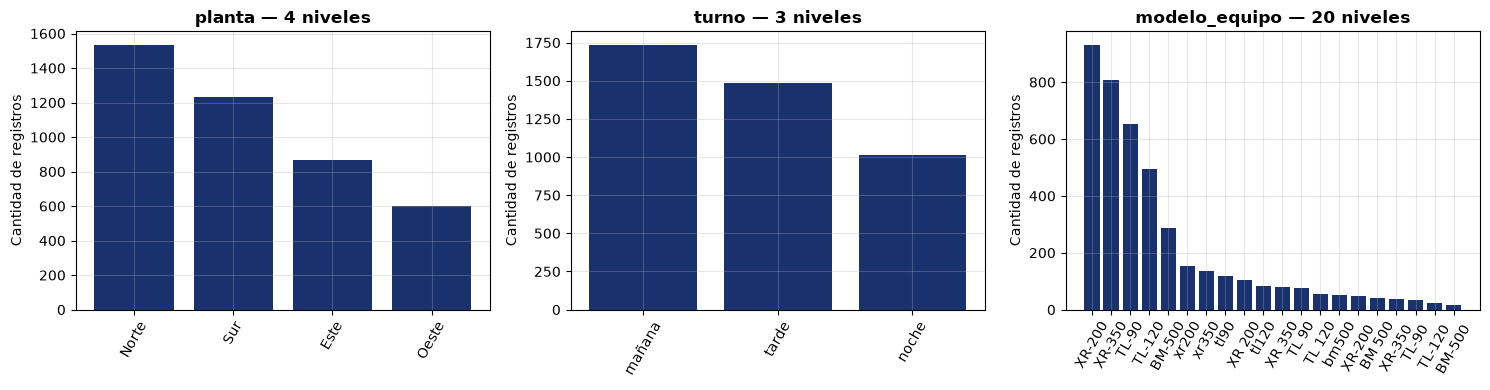

Cardinalidad de cada categórica:
  planta              4 niveles
  turno               3 niveles
  modelo_equipo      20 niveles
  id_maquina        180 niveles


In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["planta", "turno", "modelo_equipo"]):
    frec = tabla_frecuencias(df[col])
    ax.bar(frec.index.astype(str), frec["n"], color="#19326E")
    ax.set_title(f"{col} — {df[col].nunique()} niveles", fontweight="bold")
    ax.set_ylabel("Cantidad de registros")
    ax.tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()

print("Cardinalidad de cada categórica:")
for col in ["planta", "turno", "modelo_equipo", "id_maquina"]:
    print(f"  {col:16s} {df[col].nunique():4d} niveles")

### DECIDE

El gráfico de `modelo_equipo` muestra más barras de las que hay modelos de equipo.

1. Inspeccionar los niveles y explicar qué ocurrió. ¿Cuántos modelos distintos hay realmente?
2. `id_maquina` tiene 180 niveles. Si se codificara con *one-hot encoding*, ¿cuántas columnas
   agregaría? ¿Corresponde usarla como predictora tal cual está?

In [ ]:
print(sorted(df["modelo_equipo"].unique())) 

[' BM-500 ', ' TL-120 ', ' TL-90 ', ' XR-200 ', ' XR-350 ', 'BM 500', 'BM-500', 'TL 120', 'TL 90', 'TL-120', 'TL-90', 'XR 200', 'XR 350', 'XR-200', 'XR-350', 'bm500', 'tl120', 'tl90', 'xr200', 'xr350']


**Respuesta:**

1. La columna parece tener 20 niveles, pero en realidad hay 5 modelos distintos: BM-500, TL-120, TL-90, XR-200 y XR-350. Aparecen escritos de distintas maneras: con espacios al principio o al final, espacios en lugar de guiones y letras minúsculas. Antes de modelar habría que normalizar los textos para unificar esas variantes.

2. Si se aplicara one-hot encoding a id_maquina, se generarían 180 columnas binarias —o 179 si se elimina una categoría de referencia con drop="first"—. No conviene utilizarla directamente como predictora porque es un identificador con alta cardinalidad, no una característica propia de la máquina. Podría aumentar mucho la dimensionalidad y hacer que el modelo memorice máquinas concretas en lugar de aprender patrones generalizables.

## 5. Histograma y densidad: la forma depende de una decisión

El ancho de barra no es un detalle de presentación: **decide qué se ve**. La regla de
Freedman–Diaconis lo fija a partir del IQR, así que es robusta:

$$h_{\text{FD}} = 2\,\frac{\text{IQR}}{n^{1/3}}$$

y la cantidad de barras es el rango dividido por ese ancho.

In [ ]:
def ancho_freedman_diaconis(x: np.ndarray) -> float:
    """Ancho de barra de Freedman-Diaconis.

    Parámetros
    ----------
    x : np.ndarray de forma (n,), sin NaN.

    Devuelve
    --------
    float : 2 * IQR / n**(1/3).
    """
    q1 = np.percentile(x, 25)
    q3 = np.percentile(x, 75)

    iqr = q3 - q1
    n = len(x)

    ancho = 2 * iqr / n ** (1 / 3)

    return float(ancho)

In [ ]:
# VERIFICACIÓN
temp = limpio["temperatura_c"].dropna().to_numpy()
h = ancho_freedman_diaconis(temp)
n_barras = int(np.ceil((temp.max() - temp.min()) / h))
print(f"h_FD = {h:.3f} °C  ->  {n_barras} barras")

esperado = np.histogram_bin_edges(temp, bins="fd")
assert abs(len(esperado) - 1 - n_barras) <= 1, "no coincide con la regla 'fd' de NumPy"
print("Correcto: coincide con np.histogram_bin_edges(..., bins='fd')")

h_FD = 2.160 °C  ->  23 barras
Correcto: coincide con np.histogram_bin_edges(..., bins='fd')


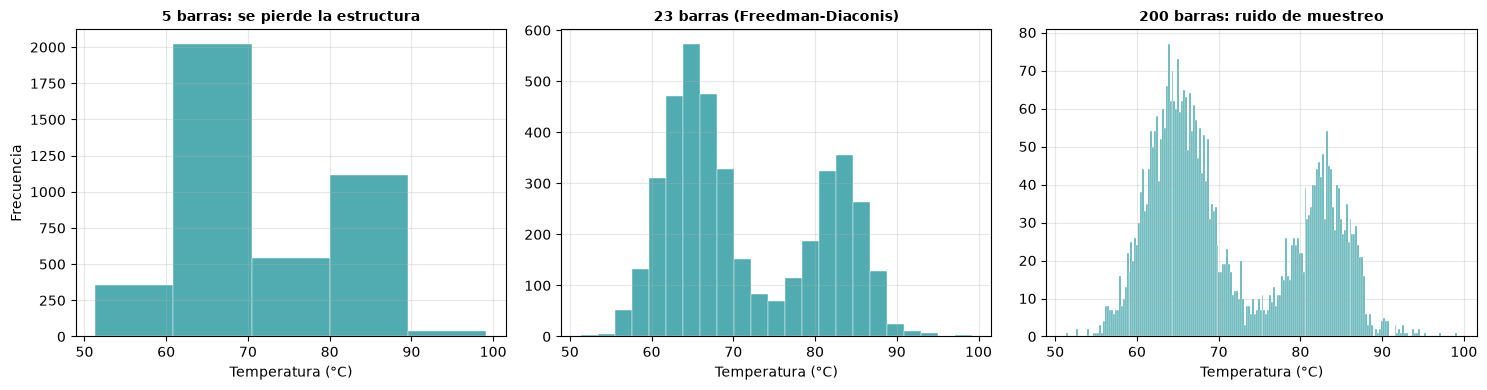

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, bins, titulo in zip(
    axes, [5, n_barras, 200],
    ["5 barras: se pierde la estructura",
     f"{n_barras} barras (Freedman-Diaconis)",
     "200 barras: ruido de muestreo"],
):
    ax.hist(temp, bins=bins, color="#50ACB0", edgecolor="white", linewidth=0.3)
    ax.set_title(titulo, fontweight="bold", fontsize=10)
    ax.set_xlabel("Temperatura (°C)")
axes[0].set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

La densidad por núcleos no elimina la decisión: la traslada del ancho de barra al **ancho
de banda**. Su apariencia continua transmite una confianza que el método no garantiza.

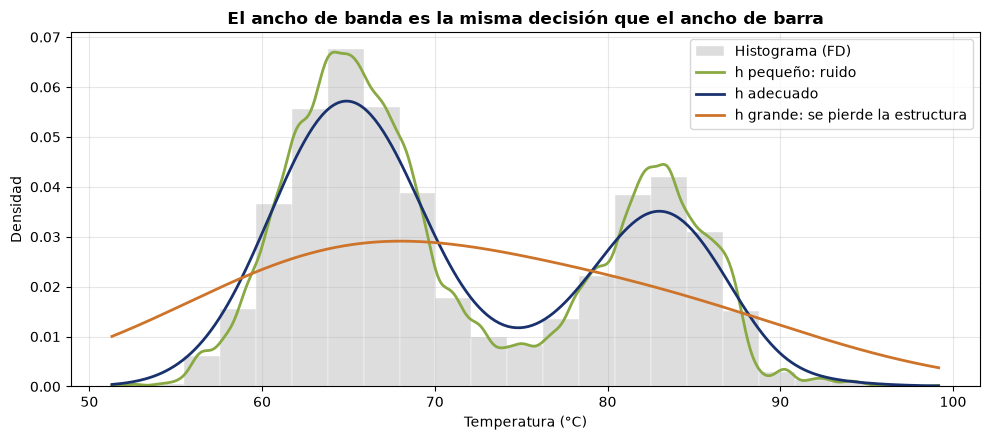

In [ ]:
rejilla = np.linspace(temp.min(), temp.max(), 400)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(temp, bins=n_barras, density=True, color="#DDDDDD", edgecolor="white",
        linewidth=0.3, label="Histograma (FD)")
for bw, color, etiqueta in [(0.05, "#89A943", "h pequeño: ruido"),
                            (0.25, "#19326E", "h adecuado"),
                            (1.00, "#CD742A", "h grande: se pierde la estructura")]:
    densidad = stats.gaussian_kde(temp, bw_method=bw)
    ax.plot(rejilla, densidad(rejilla), color=color, linewidth=2, label=etiqueta)
ax.set_xlabel("Temperatura (°C)")
ax.set_ylabel("Densidad")
ax.set_title("El ancho de banda es la misma decisión que el ancho de barra", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

In [39]:
# Asimetría y curtosis de las cuatro continuas
for col in continuas:
    x = limpio[col].dropna()
    print(f"{col:20s} asimetría = {stats.skew(x):6.2f}   curtosis = {stats.kurtosis(x):8.2f}")

temperatura_c        asimetría =   0.42   curtosis =    -1.21
vibracion_mm_s       asimetría =   4.66   curtosis =    38.23
presion_bar          asimetría =   0.02   curtosis =    -0.06
consumo_kwh          asimetría =   0.44   curtosis =     0.23


### DECIDE

A partir de los histogramas, de las densidades y de los coeficientes:

1. ¿Cuál de las cuatro variables continuas es **bimodal**? ¿Qué explicación de proceso tiene?
2. ¿Cuál es la más **asimétrica**? ¿Qué le haría a un modelo que supone normalidad?
3. La bimodalidad sugiere una acción concreta sobre los datos antes de modelar. ¿Cuál?

**Respuesta:**

1. La variable bimodal es temperatura_c, porque presenta dos grupos o picos. Una posible explicación es que las máquinas trabajan bajo dos regímenes de operación diferentes, por ejemplo, un régimen de baja carga y otro de alta carga.
2. La variable más asimétrica es vibracion_mm_s, con una asimetría aproximada de 4,66. Tiene una cola muy larga hacia la derecha. Esto incumpliría el supuesto de normalidad y podría afectar un modelo sensible a valores extremos, deformando sus estimaciones y residuos.
3. Antes de modelar conviene identificar la variable que explica los dos regímenes y analizar o modelar los grupos por separado. También se podría incorporar el régimen de operación como una variable categórica, para que el modelo no trate ambas poblaciones como si fueran una sola.

## 6. El diagrama de caja, construido desde cero

Los cinco números del diagrama de caja son $Q_1$, la mediana, $Q_3$ y los dos bigotes. El punto
que más se confunde es el bigote: **no llega al límite calculado**, sino al dato más extremo que
todavía cae dentro de él.

In [41]:
def cinco_numeros(x: np.ndarray, k: float = 1.5) -> dict[str, float]:
    """Los cinco números del diagrama de caja, más los límites que no se dibujan.

    Parámetros
    ----------
    x : np.ndarray de forma (n,), sin NaN.
    k : multiplicador del IQR (1,5 es la convención de Tukey).

    Devuelve
    --------
    dict con las claves:
      "q1", "mediana", "q3", "iqr"       -> la caja
      "limite_inf", "limite_sup"         -> Q1 - k*IQR y Q3 + k*IQR (no se dibujan)
      "bigote_inf", "bigote_sup"         -> el dato más extremo DENTRO de cada límite
      "n_atipicos"                       -> cuántas observaciones quedan fuera
    """
    q1 = np.percentile(x, 25)
    mediana = np.percentile(x, 50)
    q3 = np.percentile(x, 75)

    iqr = q3 - q1

    limite_inf = q1 - k * iqr
    limite_sup = q3 + k * iqr

    dentro = x[
        (x >= limite_inf) &
        (x <= limite_sup)
    ]

    bigote_inf = dentro.min()
    bigote_sup = dentro.max()

    atipicos = (
        (x < limite_inf) |
        (x > limite_sup)
    )

    return {
        "q1": float(q1),
        "mediana": float(mediana),
        "q3": float(q3),
        "iqr": float(iqr),
        "limite_inf": float(limite_inf),
        "limite_sup": float(limite_sup),
        "bigote_inf": float(bigote_inf),
        "bigote_sup": float(bigote_sup),
        "n_atipicos": int(atipicos.sum())
    }

In [42]:
# VERIFICACIÓN — contra el cálculo que hace matplotlib para dibujar el boxplot
from matplotlib.cbook import boxplot_stats

vib = limpio["vibracion_mm_s"].dropna().to_numpy()
mio = cinco_numeros(vib)
ref = boxplot_stats(vib)[0]

assert np.isclose(mio["mediana"], ref["med"]), "mediana"
assert np.isclose(mio["q1"], ref["q1"]) and np.isclose(mio["q3"], ref["q3"]), "cuartiles"
assert np.isclose(mio["bigote_inf"], ref["whislo"]), "el bigote inferior no es un dato real"
assert np.isclose(mio["bigote_sup"], ref["whishi"]), "el bigote superior no es un dato real"
assert mio["n_atipicos"] == len(ref["fliers"]), "cantidad de atípicos"

for clave, valor in mio.items():
    print(f"  {clave:12s} {valor:10.3f}")
print("\nCorrecto: coincide con matplotlib.cbook.boxplot_stats")

  q1                1.416
  mediana           1.878
  q3                2.529
  iqr               1.113
  limite_inf       -0.253
  limite_sup        4.197
  bigote_inf        0.386
  bigote_sup        4.177
  n_atipicos      199.000

Correcto: coincide con matplotlib.cbook.boxplot_stats


La distancia entre el límite calculado y el bigote efectivo es lo que hace que los bigotes
no sean simétricos ni predecibles: su largo lo fija un dato, no una fórmula.

In [43]:
print(f"límite superior calculado : {mio['limite_sup']:.3f}")
print(f"bigote superior dibujado  : {mio['bigote_sup']:.3f}  (un dato real)")
print(f"observaciones fuera       : {mio['n_atipicos']} de {vib.size} "
      f"({100 * mio['n_atipicos'] / vib.size:.1f} %)")

límite superior calculado : 4.197
bigote superior dibujado  : 4.177  (un dato real)
observaciones fuera       : 199 de 3804 (5.2 %)


Un diagrama de caja **nunca se lee solo**. Acompañarlo con los puntos superpuestos muestra
lo que los cinco números no pueden mostrar: cuántas observaciones hay en cada zona y si la
distribución tiene una o dos modas.

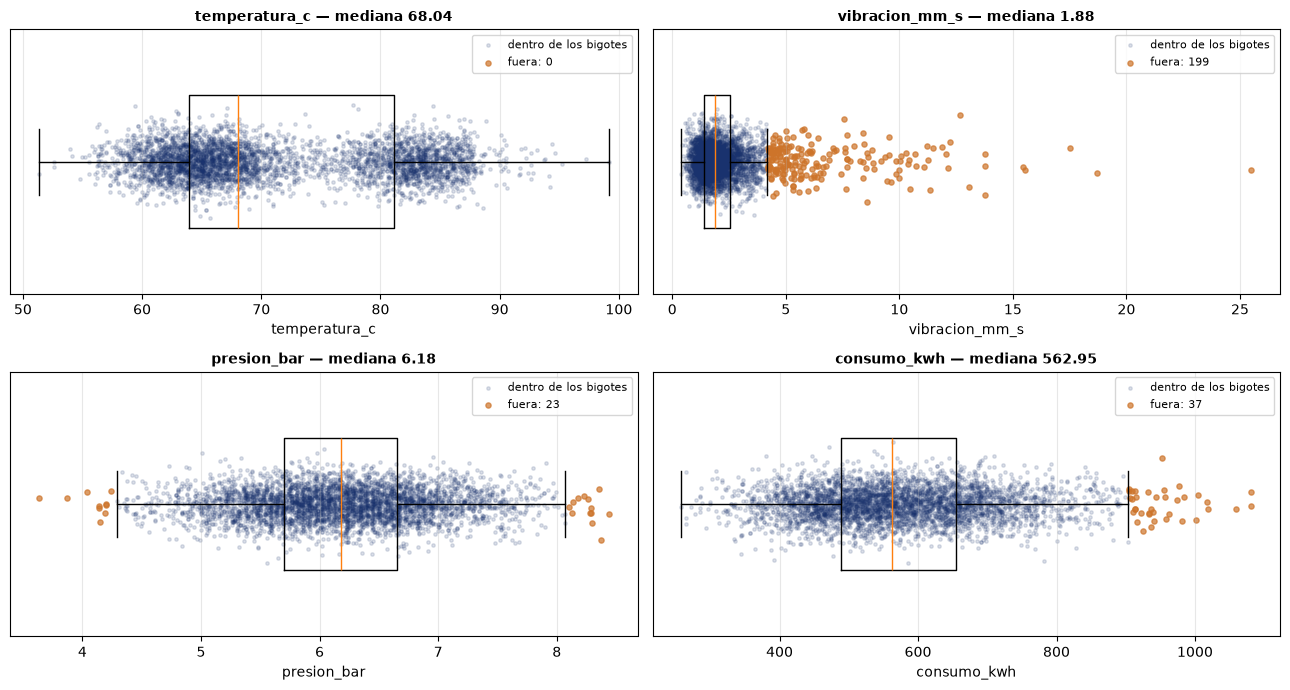

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
rng = np.random.default_rng(20260806)

for ax, col in zip(axes.ravel(), continuas):
    x = limpio[col].dropna().to_numpy()
    cinco = cinco_numeros(x)
    fuera = (x < cinco["limite_inf"]) | (x > cinco["limite_sup"])

    ax.boxplot(x, orientation="horizontal", widths=0.5, showfliers=False)
    ruido = rng.normal(1.0, 0.06, size=x.size)
    ax.scatter(x[~fuera], ruido[~fuera], s=6, alpha=0.15, color="#19326E",
               label="dentro de los bigotes")
    ax.scatter(x[fuera], ruido[fuera], s=14, alpha=0.7, color="#CD742A",
               label=f"fuera: {int(fuera.sum())}")
    ax.set_yticks([])
    ax.set_xlabel(col)
    ax.set_title(f"{col} — mediana {cinco['mediana']:.2f}", fontweight="bold", fontsize=10)
    ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

### Para analizar

1. En `temperatura_c`, ¿la mediana cae en una zona densa de observaciones o en un valle entre
   dos grupos? ¿Qué implica eso para un informe que reporte «la temperatura mediana»?
2. `presion_bar` y `consumo_kwh` marcan pocos puntos fuera; `vibracion_mm_s` marca muchos. ¿La
   diferencia es de calidad de los datos o de forma de la distribución?

**Respuesta:**

1. En temperatura_c, la mediana cae en un valle entre los dos grupos, no en una zona con muchas observaciones. Por eso, aunque sea matemáticamente correcta, reportarla como “temperatura típica” sería engañoso: representa un valor poco frecuente y oculta que existen dos regímenes de operación.
2. La diferencia se debe principalmente a la forma de las distribuciones, no necesariamente a la calidad de los datos. vibracion_mm_s tiene una fuerte asimetría y una cola derecha larga, por lo que la regla del IQR marca muchos valores altos. Esos puntos pueden ser mediciones reales asociadas al funcionamiento o a fallos, y no errores que deban eliminarse automáticamente.

El diagrama de caja se vuelve mucho más informativo comparando grupos, porque ahí la
pregunta pasa a ser cuánto cambia la distribución **según** otra variable.

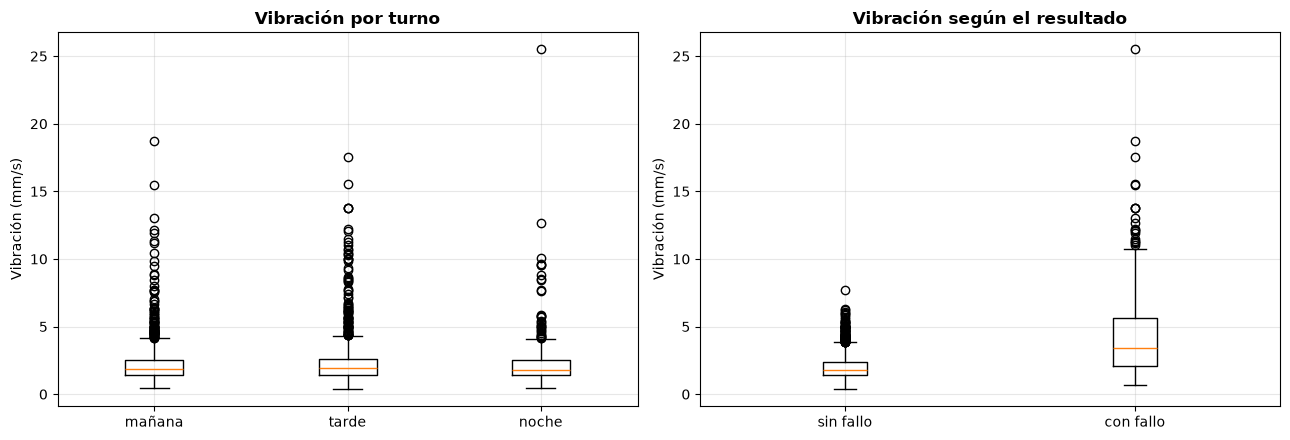

        count  mean   std   min   25%   50%   75%    max
fallo                                                   
0      3441.0  1.97  0.83  0.39  1.38  1.82  2.37   7.70
1       363.0  4.44  3.32  0.66  2.12  3.38  5.66  25.51


In [45]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

grupos_turno = [limpio.loc[limpio["turno"] == t, "vibracion_mm_s"].dropna()
                for t in ["mañana", "tarde", "noche"]]
ax1.boxplot(grupos_turno, tick_labels=["mañana", "tarde", "noche"])
ax1.set_ylabel("Vibración (mm/s)")
ax1.set_title("Vibración por turno", fontweight="bold")

grupos_fallo = [limpio.loc[limpio["fallo"] == v, "vibracion_mm_s"].dropna() for v in [0, 1]]
ax2.boxplot(grupos_fallo, tick_labels=["sin fallo", "con fallo"])
ax2.set_ylabel("Vibración (mm/s)")
ax2.set_title("Vibración según el resultado", fontweight="bold")

plt.tight_layout()
plt.show()

print(limpio.groupby("fallo")["vibracion_mm_s"].describe().round(2).to_string())

### Para analizar

La vibración alta pertenece mayoritariamente a las máquinas que fallaron.

1. Si se «limpiaran los atípicos» de `vibracion_mm_s` antes de modelar, ¿qué se estaría
   eliminando?
2. ¿En qué se diferencia ese caso del de los 999 en `temperatura_c`?

**Respuesta:**

1. Al eliminar los valores atípicos de vibracion_mm_s, se estarían eliminando principalmente observaciones reales de máquinas que fallaron. Esto quitaría información importante relacionada con la variable objetivo y podría dificultar que el modelo aprenda a detectar los fallos.
2. El valor 999 en temperatura_c es un código de error o una medición imposible, no una temperatura real. En cambio, las vibraciones altas son valores posibles y aportan información sobre el estado de las máquinas. Por eso, 999 debe reemplazarse por faltante, mientras que las vibraciones altas no deben eliminarse automáticamente.

## 7. Criterios de atípicos: qué marca cada uno

Los dos criterios univariados de la clase se diferencian **solo** en con qué miden el centro y
con qué miden la escala: la regla del IQR usa cuartiles, el z-score usa media y desvío.

In [46]:
def marcar_iqr(x: np.ndarray, k: float = 1.5) -> np.ndarray:
    """Marca atípicos con la regla del diagrama de caja.

    Parámetros
    ----------
    x : np.ndarray de forma (n,), sin NaN.
    k : multiplicador del IQR.

    Devuelve
    --------
    np.ndarray booleano de forma (n,): True donde la observación queda fuera de los límites.
    """
    q1 = np.percentile(x, 25)
    q3 = np.percentile(x, 75)

    iqr = q3 - q1

    limite_inf = q1 - k * iqr
    limite_sup = q3 + k * iqr

    return (
        (x < limite_inf) |
        (x > limite_sup)
    )


def marcar_zscore(x: np.ndarray, umbral: float = 3.0) -> np.ndarray:
    """Marca atípicos con el z-score clásico.

    Parámetros
    ----------
    x : np.ndarray de forma (n,), sin NaN.
    umbral : valor absoluto de z por encima del cual se marca la observación.

    Devuelve
    --------
    np.ndarray booleano de forma (n,).
    """

    promedio = x.mean()
    desvio = x.std(ddof=1)

    z = (x - promedio) / desvio

    return np.abs(z) > umbral
    

In [47]:
# VERIFICACIÓN
prueba = np.array([10.0, 11, 12, 13, 14, 15, 16, 17, 18, 100])
assert marcar_iqr(prueba)[-1], "el valor 100 debe quedar marcado por la regla del IQR"
assert marcar_iqr(prueba).sum() == 1, "solo el valor 100 debe quedar marcado"
assert marcar_iqr(np.arange(100.0)).sum() == 0, "una uniforme no debería marcar nada"

m_iqr, m_z = marcar_iqr(vib), marcar_zscore(vib)
print(f"vibracion_mm_s: n = {len(vib)}")
print(f"  regla 1,5·IQR marca {m_iqr.sum():4d}  ({m_iqr.mean():.1%})")
print(f"  z-score > 3   marca {m_z.sum():4d}  ({m_z.mean():.1%})")
assert m_iqr.sum() == 199, f"se esperaban 199, se obtuvieron {m_iqr.sum()}"
print("Correcto")

vibracion_mm_s: n = 3804
  regla 1,5·IQR marca  199  (5.2%)
  z-score > 3   marca   67  (1.8%)
Correcto


Bajo normalidad, la regla $1{,}5\,$IQR marca alrededor del 0,7 % de las observaciones. Acá
marca el 5,2 %: siete veces más. No hay siete veces más anomalías; lo que el criterio está
detectando es **la forma de la distribución**, porque su calibración supone simetría.

El z-score tiene un problema propio, y es más grave. Corresponde comprobarlo sobre el
ejemplo de la clase: nueve mediciones de un sensor y una décima observación aberrante.

In [48]:
nueve = np.array([48.0, 51, 49, 52, 50, 47, 53, 49, 51])

print(f"{'décima obs.':>12} {'s':>10} {'|z| de la décima':>18} {'¿marca?':>10}")
for extra in [60.0, 500.0, 5000.0]:
    x = np.append(nueve, extra)
    z = abs((extra - x.mean()) / x.std(ddof=1))
    print(f"{extra:12.0f} {x.std(ddof=1):10.2f} {z:18.2f} {str(z > 3):>10}")

n = 10
print(f"\nCota teórica del z-score con n = {n}: (n-1)/sqrt(n) = {(n - 1) / np.sqrt(n):.3f}")
print("Con umbral 3, ninguna observación puede ser marcada: el umbral es inalcanzable.")

 décima obs.          s   |z| de la décima    ¿marca?
          60       3.65               2.46      False
         500     142.31               2.85      False
        5000    1565.33               2.85      False

Cota teórica del z-score con n = 10: (n-1)/sqrt(n) = 2.846
Con umbral 3, ninguna observación puede ser marcada: el umbral es inalcanzable.


### Para analizar

1. Al pasar de 60 a 5000, la observación se vuelve muchísimo más extrema y su $|z|$ casi no se
   mueve. ¿Por qué?
2. ¿Qué criterio de los dos habría marcado la observación 500? Comprobarlo.

In [49]:
# TODO: aplicar marcar_iqr al arreglo de diez valores con la décima observación en 500
#       e informar cuántas y cuáles observaciones quedan marcadas.
x = np.append(nueve, 500.0)

marcas = marcar_iqr(x)

print("Cantidad marcada:", marcas.sum())
print("Valores marcados:", x[marcas])

Cantidad marcada: 1
Valores marcados: [500.]


**Respuesta:**

1. Porque el valor extremo también aumenta la media y el desvío estándar utilizados para calcular su propio z-score. Al pasar de 60 a 5000, la distancia respecto de la media crece, pero el desvío también aumenta mucho. Por eso, el valor de \(|z|\) casi no cambia. Esto muestra que el z-score no es resistente a valores extremos.
2. La regla del IQR marca la observación 500 como atípica, mientras que el z-score con umbral 3 no la marca. La comprobación muestra una sola observación marcada: [500.]. Esto sucede porque el IQR se basa en cuartiles, que son resistentes a un valor extremo.

## 8. Relaciones entre variables: cuando Pearson y Spearman no coinciden

Pearson mide asociación **lineal** y no resiste valores extremos. Spearman es Pearson sobre los
rangos: mide asociación **monótona** y sí los resiste. Cuando los dos difieren mucho, la
diferencia misma es el hallazgo.

In [50]:
def divergencia_pearson_spearman(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """Ordena los pares de variables según cuánto difieren Pearson y Spearman.

    Parámetros
    ----------
    df : DataFrame con las variables.
    cols : columnas numéricas a considerar.

    Devuelve
    --------
    pd.DataFrame con columnas ["var_1", "var_2", "pearson", "spearman", "divergencia"],
    ordenado por "divergencia" de mayor a menor. Una fila por par, sin repetir A-B y B-A.
    """
  

    filas = []

    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            var_1 = cols[i]
            var_2 = cols[j]

            datos = df[[var_1, var_2]].dropna()

            pearson = datos[var_1].corr(
                datos[var_2],
                method="pearson"
            )

            spearman = datos[var_1].corr(
                datos[var_2],
                method="spearman"
            )

            filas.append({
                "var_1": var_1,
                "var_2": var_2,
                "pearson": pearson,
                "spearman": spearman,
                "divergencia": abs(pearson - spearman)
            })

    resultado = pd.DataFrame(filas)

    resultado = resultado.sort_values(
        "divergencia",
        ascending=False
    ).reset_index(drop=True)

    return resultado

In [51]:
# VERIFICACIÓN
ranking = divergencia_pearson_spearman(limpio, numericas)
print(ranking.head(5).round(3).to_string(index=False))

peor = ranking.iloc[0]
assert {peor.var_1, peor.var_2} == {"horas_operacion", "antiguedad_meses"}, \
    "el par más divergente debería ser horas_operacion / antiguedad_meses"
print(f"\nCorrecto: {peor.var_1} vs {peor.var_2} -> "
      f"Pearson {peor.pearson:.3f} contra Spearman {peor.spearman:.3f}")

          var_1                    var_2  pearson  spearman  divergencia
horas_operacion         antiguedad_meses    0.159     0.863        0.704
    consumo_kwh          horas_operacion    0.137     0.686        0.548
horas_operacion n_mantenimientos_previos    0.089     0.504        0.416
  temperatura_c           vibracion_mm_s    0.104     0.051        0.052
    consumo_kwh         antiguedad_meses    0.659     0.607        0.052

Correcto: horas_operacion vs antiguedad_meses -> Pearson 0.159 contra Spearman 0.863


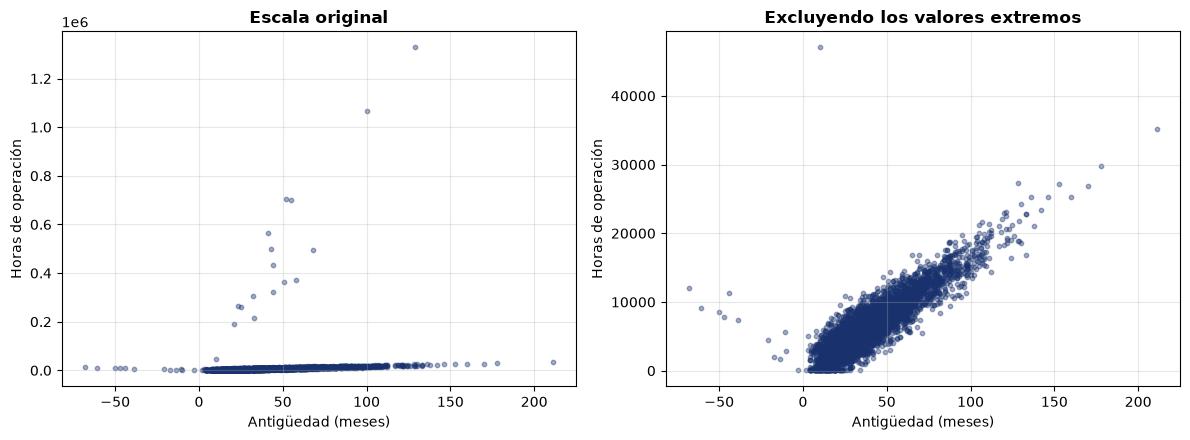

Registros con horas_operacion > 100.000: 16


In [52]:
# El gráfico que explica la divergencia
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.scatter(limpio["antiguedad_meses"], limpio["horas_operacion"], s=10, alpha=0.4,
            color="#19326E")
ax1.set_xlabel("Antigüedad (meses)"); ax1.set_ylabel("Horas de operación")
ax1.set_title("Escala original", fontweight="bold")

mask = limpio["horas_operacion"] < 100_000
ax2.scatter(limpio.loc[mask, "antiguedad_meses"], limpio.loc[mask, "horas_operacion"],
            s=10, alpha=0.4, color="#19326E")
ax2.set_xlabel("Antigüedad (meses)"); ax2.set_ylabel("Horas de operación")
ax2.set_title("Excluyendo los valores extremos", fontweight="bold")
plt.tight_layout(); plt.show()

print(f"Registros con horas_operacion > 100.000: {(~mask).sum()}")

### Para analizar

1. ¿Cuántos registros producen la divergencia y qué porcentaje del total representan?
2. ¿Qué defecto concreto tienen esos registros? Verificar la hipótesis con una cuenta.
3. ¿Cuál de los dos coeficientes describe mejor la relación real entre antigüedad y horas?

**Respuesta:**

1. La divergencia es producida por 16 registros. Sobre un total de 4237, representan aproximadamente:
\[
\frac{16}{4237}\times100 = 0,38\%
\]
2. Esos 16 registros tienen horas_operacion mayores a 100.000 y parecen estar cargados en minutos en lugar de horas. Los valores son múltiplos de 60; al dividirlos por 60 vuelven a una escala razonable. Es un error de unidad.
3. Spearman describe mejor la relación real entre antiguedad_meses y horas_operacion. Su valor es aproximadamente 0,863, mostrando una relación positiva fuerte. Pearson da aproximadamente 0,159 porque los 16 errores extremos distorsionan mucho la correlación lineal. Spearman trabaja con rangos y es más resistente a esos extremos.

## 9. Datos faltantes: el mecanismo decide el tratamiento

Contar faltantes por columna es el primer paso, no el último. Lo que decide el tratamiento es
**por qué** faltan.

In [53]:
faltan = limpio.isna().sum()
print("Faltantes por variable:")
print(faltan[faltan > 0].to_string())
print()

for col in ["consumo_kwh", "vibracion_mm_s"]:
    print(f"--- Tasa de faltantes de {col} por grupo ---")
    for grupo in ["planta", "turno"]:
        tasa = limpio.assign(f=limpio[col].isna()).groupby(grupo)["f"].mean() * 100
        print(f"  por {grupo}: " + "  ".join(f"{k}={v:.1f}%" for k, v in tasa.items()))
    print()

obs = limpio["temperatura_c"].dropna()
print("--- temperatura_c (ya sin el código 999) ---")
print(f"  máximo observado: {obs.max():.1f} °C")
print(f"  faltantes: {int(limpio['temperatura_c'].isna().sum())}")

Faltantes por variable:
temperatura_c            162
vibracion_mm_s           433
presion_bar               45
consumo_kwh              259
costo_reparacion_usd    3829

--- Tasa de faltantes de consumo_kwh por grupo ---
  por planta: Este=6.6%  Norte=6.0%  Oeste=6.7%  Sur=5.7%
  por turno: mañana=6.6%  noche=6.0%  tarde=5.6%

--- Tasa de faltantes de vibracion_mm_s por grupo ---
  por planta: Este=8.6%  Norte=10.9%  Oeste=10.7%  Sur=10.2%
  por turno: mañana=3.3%  noche=33.1%  tarde=2.6%

--- temperatura_c (ya sin el código 999) ---
  máximo observado: 99.2 °C
  faltantes: 162


In [54]:
print("Presencia de costo_reparacion_usd según el resultado:")
print(pd.crosstab(limpio["fallo"], limpio["costo_reparacion_usd"].notna(),
                  rownames=["fallo"], colnames=["costo informado"]))

Presencia de costo_reparacion_usd según el resultado:
costo informado  False  True 
fallo                        
0                 3829      0
1                    0    408


### DECIDE

1. Clasificar el mecanismo de `consumo_kwh`, `vibracion_mm_s` y `temperatura_c` en MCAR, MAR o
   MNAR, citando la evidencia de las celdas anteriores.
2. `costo_reparacion_usd` falta en el 90 % de los registros y está presente **exactamente** en
   los que tienen `fallo = 1`. ¿Es una variable con faltantes? ¿Puede usarse como predictora?
3. ¿Cuál de los tres mecanismos **no** se puede diagnosticar con los datos disponibles, y qué
   haría falta para detectarlo?

**Respuesta:**

1. consumo_kwh es compatible con MCAR, porque su porcentaje de faltantes es parecido entre plantas (aproximadamente 5,7 % a 6,7 %) y turnos (5,6 % a 6,6 %), sin una asociación clara con las variables observadas.  
vibracion_mm_s es MAR, porque sus faltantes dependen del turno, una variable observada: en el turno noche falta aproximadamente el 33,1 %, mientras que en mañana y tarde falta solamente alrededor del 3 %.  
temperatura_c es compatible con MNAR, porque los faltantes podrían depender del propio valor de temperatura no observado, por ejemplo si el sensor falla o se satura cuando la temperatura es demasiado elevada. El código imposible 999 también muestra un problema en el proceso de medición.
2. costo_reparacion_usd no tiene faltantes comunes, sino valores no aplicables: solo existe un costo de reparación cuando hubo un fallo. No debe usarse como predictora porque se conoce después de que ocurre el fallo y revela perfectamente la variable objetivo: está presente en los 408 casos con fallo = 1 y ausente en los 3829 casos con fallo = 0. Utilizarla produciría fuga de información.
3. El mecanismo que no puede diagnosticarse únicamente con los datos disponibles es MNAR, porque no conocemos los valores que faltan y, por lo tanto, no podemos comprobar si la ausencia depende de ellos. Harían falta datos externos, mediciones de otro sensor, registros del proceso de captura o recuperar una muestra de los valores faltantes.

## 10. Informe de hallazgos

Es el entregable. Una fila por hallazgo, con las cuatro columnas completas. Un hallazgo sin
evidencia numérica no es un hallazgo, y una decisión sin justificación no es auditable.

### Hallazgos

| Evidencia | Criterio | Decisión | Justificación |
|---|---|---|---|
| *ej.: `temperatura_c` toma el valor 999,0 en 31 registros* | *repetición exacta + fuera de la valla 3·IQR* | *reemplazar por faltante y registrar* | *no es una temperatura posible; conservarlo multiplica el desvío por 8,7* |
|  |  |  |  |
|  |  |  |  |
|  |  |  |  |
|  |  |  |  |
|  |  |  |  |

### Tres consecuencias para el modelado

Cada una debe seguirse de un hallazgo de la tabla.

1. Los códigos imposibles 999 de temperatura_c y -1 de presion_bar deben reemplazarse por valores faltantes y tratarse mediante una estrategia de imputación; mantenerlos distorsionaría las escalas y los parámetros del modelo.
2. No se deben eliminar automáticamente los valores altos de vibracion_mm_s, porque son mediciones reales asociadas con los fallos. Eliminarlos quitaría información predictiva importante y dificultaría que el modelo reconozca máquinas con riesgo de fallo.
3. costo_reparacion_usd debe excluirse de las variables predictoras porque solo está disponible después de producirse un fallo y revela directamente la variable objetivo. Incluirlo provocaría fuga de información y una evaluación artificialmente optimista.

## Cierre

- Un resumen numérico comprime, y al comprimir esconde. Cada estadístico de este laboratorio
  tuvo que mirarse junto a un gráfico para significar algo.
- Los criterios de atípicos no son neutrales: cada uno supone una forma. Cuando el supuesto no
  se cumple, el criterio detecta la forma de la distribución, no anomalías.
- Un atípico no es un error: es una observación que hay que explicar. En este conjunto conviven
  las cuatro causas, y cada una pide un tratamiento distinto.

Lo que no se haya completado durante la clase se termina fuera de ella. El informe de la sección
10 se entrega completo, con las cuatro columnas y las tres consecuencias.

## Para seguir explorando

- Repetir el análisis de la sección 6 sobre `temperatura_c` separando por régimen de operación
  (por encima y por debajo de 75 °C). ¿Qué pasa con la cantidad de atípicos marcados?
- Comparar la cantidad de atípicos que marca la regla $1{,}5\,$IQR sobre `vibracion_mm_s` antes y
  después de aplicar una transformación logarítmica. Interpretar el cambio.